# Day 5 — Baseline Model Inspection

Goal: inspect the baseline probability model API and confirm it can fit and predict probabilities.

This notebook does not create final prediction artifacts.

Production model logic lives in:

- `src/fbsystem/models/baseline.py`

Input:

- `data/processed/matches_with_market_probs.parquet`

Day 6 will handle walk-forward predictions and edge calculation.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [3]:
from fbsystem.models.baseline import (
    BASELINE_FEATURE_COLUMNS,
    MODEL_PROB_COLUMNS,
    build_baseline_model_report,
    evaluate_baseline_probabilities,
    fit_baseline_model,
    predict_baseline_probabilities,
)

In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "matches_with_market_probs.parquet"

assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH)

df.shape

(14597, 26)

In [5]:
df.groupby("season").size()

season
2021-2022    3086
2022-2023    3086
2023-2024    3016
2024-2025    3016
2025-2026    2393
dtype: int64

In [6]:
df[BASELINE_FEATURE_COLUMNS].head()

,market_home_prob,market_draw_prob,market_away_prob,season_start_year,source_country,source_league_code
0,0.294829,0.251588,0.453583,2021,belgium,B1
1,0.255273,0.296472,0.448255,2021,mexico,MEX
2,0.529843,0.252848,0.217309,2021,belgium,B1
3,0.419176,0.276583,0.304241,2021,belgium,B1
4,0.479204,0.238995,0.281801,2021,belgium,B1


In [7]:
df["full_time_result"].value_counts(normalize=True).sort_index()

full_time_result
A    0.310612
D    0.252244
H    0.437145
Name: proportion, dtype: float64

In [8]:
model = fit_baseline_model(df)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [9]:
probabilities = predict_baseline_probabilities(model, df)

probabilities.head()

,model_home_prob,model_draw_prob,model_away_prob
0,0.259001,0.259941,0.481058
1,0.227317,0.287035,0.485648
2,0.544003,0.259108,0.196889
3,0.406141,0.293569,0.300291
4,0.483065,0.260374,0.256561


In [10]:
probability_sums = probabilities[MODEL_PROB_COLUMNS].sum(axis=1)

probability_sums.describe()

count    1.459700e+04
mean     1.000000e+00
std      6.729096e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [11]:
(probability_sums - 1.0).abs().max()

np.float64(2.220446049250313e-16)

In [12]:
metrics = evaluate_baseline_probabilities(
    y_true=df["full_time_result"],
    probability_df=probabilities,
)

report = build_baseline_model_report(metrics)

report

c:\Users\jaymi\Projects\Continuous Projects\football-decision-system\.venv\Lib\site-packages\sklearn\metrics\_classification.py:198: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


,metric,value
0,n_rows,1.459700e+04
1,accuracy,5.406590e-01
2,log_loss,1.476816e+00
3,mean_home_prob,4.371191e-01
4,mean_draw_prob,2.522423e-01
5,mean_away_prob,3.106386e-01
6,min_probability_sum,1.000000e+00
7,max_probability_sum,1.000000e+00
8,max_abs_probability_sum_error,2.220446e-16


In [13]:
comparison = pd.concat(
    [
        df[
            [
                "match_date",
                "season",
                "source_country",
                "source_league_code",
                "home_team",
                "away_team",
                "full_time_result",
                "market_home_prob",
                "market_draw_prob",
                "market_away_prob",
            ]
        ],
        probabilities,
    ],
    axis=1,
)

comparison.head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,full_time_result,market_home_prob,market_draw_prob,market_away_prob,model_home_prob,model_draw_prob,model_away_prob
0,2021-07-23,2021-2022,belgium,B1,Standard,Genk,D,0.294829,0.251588,0.453583,0.259001,0.259941,0.481058
1,2021-07-23,2021-2022,mexico,MEX,Queretaro,Club America,D,0.255273,0.296472,0.448255,0.227317,0.287035,0.485648
2,2021-07-24,2021-2022,belgium,B1,Kortrijk,Seraing,H,0.529843,0.252848,0.217309,0.544003,0.259108,0.196889
3,2021-07-24,2021-2022,belgium,B1,Oostende,Charleroi,A,0.419176,0.276583,0.304241,0.406141,0.293569,0.300291
4,2021-07-24,2021-2022,belgium,B1,Oud-Heverlee Leuven,Waregem,D,0.479204,0.238995,0.281801,0.483065,0.260374,0.256561
5,2021-07-24,2021-2022,mexico,MEX,Juarez,Toluca,A,0.374448,0.291367,0.334185,0.357598,0.304630,0.337773
6,2021-07-24,2021-2022,mexico,MEX,Necaxa,Santos Laguna,A,0.332244,0.300195,0.367561,0.308723,0.308153,0.383123
7,2021-07-24,2021-2022,mexico,MEX,Pachuca,Club Leon,H,0.413651,0.275767,0.310582,0.405482,0.292203,0.302315
8,2021-07-25,2021-2022,belgium,B1,Anderlecht,St. Gilloise,A,0.463064,0.283679,0.253257,0.459341,0.294322,0.246338
9,2021-07-25,2021-2022,belgium,B1,Club Brugge,Eupen,D,0.778318,0.142476,0.079206,0.804620,0.128628,0.066751


In [15]:
summary = pd.DataFrame(
    {
        "market": [
            df["market_home_prob"].mean(),
            df["market_draw_prob"].mean(),
            df["market_away_prob"].mean(),
        ],
        "model": [
            probabilities["model_home_prob"].mean(),
            probabilities["model_draw_prob"].mean(),
            probabilities["model_away_prob"].mean(),
        ],
    },
    index=["home", "draw", "away"],
)

summary

,market,model
home,0.439063,0.437119
draw,0.248592,0.252242
away,0.312345,0.310639


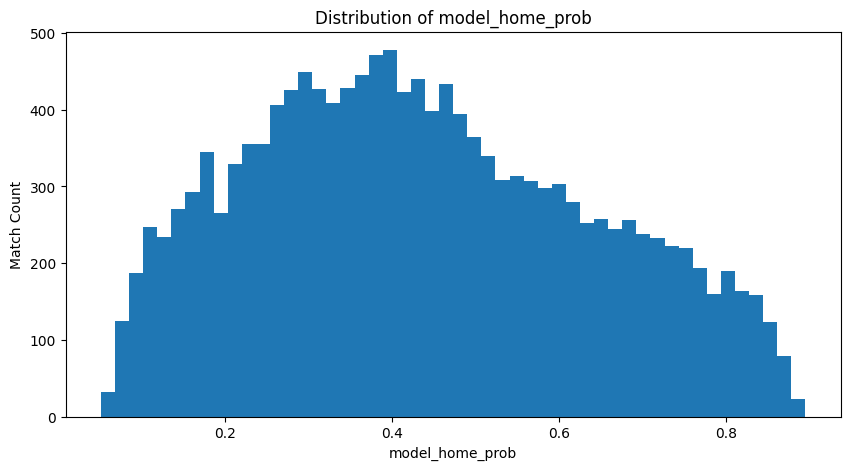

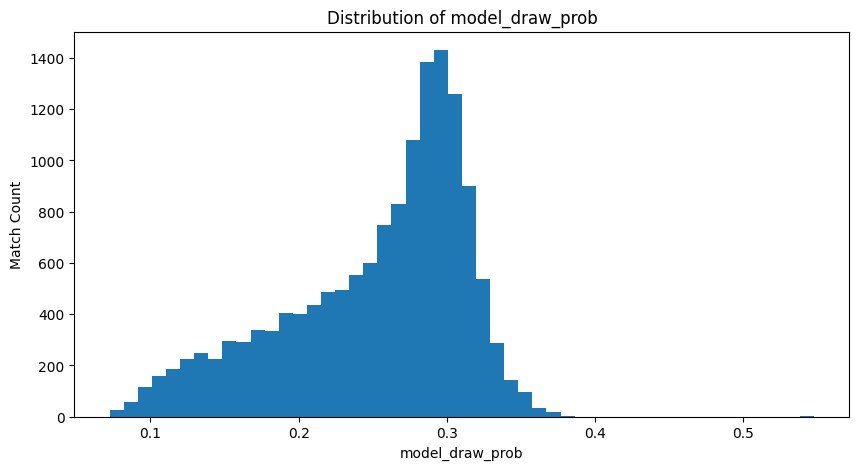

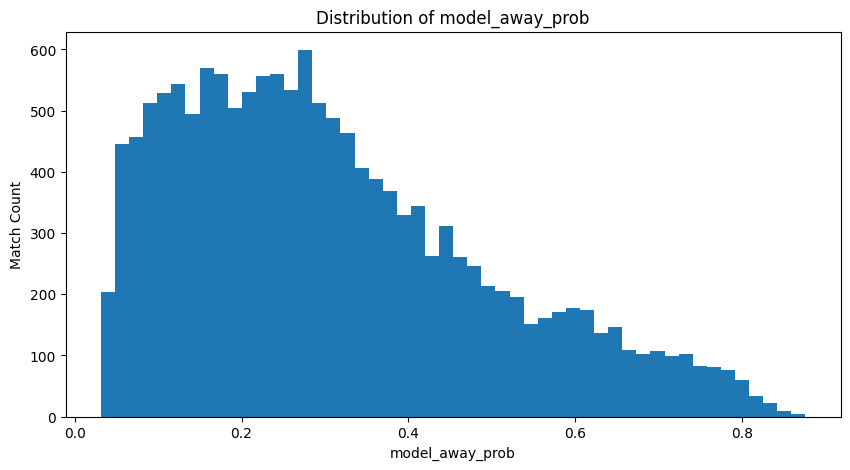

In [16]:
for col in MODEL_PROB_COLUMNS:
    plt.figure(figsize=(10, 5))
    plt.hist(probabilities[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Match Count")
    plt.show()

In [17]:
comparison.sort_values("model_home_prob", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,full_time_result,market_home_prob,market_draw_prob,market_away_prob,model_home_prob,model_draw_prob,model_away_prob
10943,2025-02-01,2024-2025,germany,D1,Bayern Munich,Holstein Kiel,H,0.924823,0.053198,0.021979,0.895554,0.073082,0.031364
6744,2023-09-30,2023-2024,netherlands,N1,PSV Eindhoven,Volendam,H,0.925930,0.050090,0.023981,0.891684,0.075247,0.033069
2254,2022-03-06,2021-2022,netherlands,N1,Ajax,Waalwijk,H,0.926290,0.053510,0.020201,0.889974,0.076187,0.033840
3242,2022-08-13,2022-2023,france,F1,Paris SG,Montpellier,H,0.904544,0.065314,0.030142,0.889648,0.073832,0.036521
9107,2024-05-18,2023-2024,portugal,P1,Sp Lisbon,Chaves,H,0.897983,0.069990,0.032028,0.888923,0.076694,0.034383
6100,2023-05-27,2022-2023,portugal,P1,Benfica,Santa Clara,H,0.898908,0.070949,0.030144,0.888458,0.076865,0.034677
7380,2023-12-07,2023-2024,netherlands,N1,Feyenoord,Volendam,H,0.917921,0.056354,0.025725,0.887545,0.078153,0.034302
8582,2024-04-04,2023-2024,england,E0,Liverpool,Sheffield United,H,0.899036,0.066160,0.034804,0.886675,0.077038,0.036287
9119,2024-05-19,2023-2024,england,E0,Man City,West Ham,H,0.898832,0.067255,0.033912,0.886462,0.077299,0.036238
1516,2021-12-22,2021-2022,netherlands,N1,Ajax,For Sittard,H,0.918380,0.058381,0.023239,0.885986,0.078818,0.035196


In [18]:
comparison.sort_values("model_away_prob", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,full_time_result,market_home_prob,market_draw_prob,market_away_prob,model_home_prob,model_draw_prob,model_away_prob
1175,2021-11-27,2021-2022,portugal,P1,Belenenses,Benfica,A,0.026144,0.072521,0.901335,0.051518,0.072420,0.876062
1130,2021-11-21,2021-2022,netherlands,N1,Waalwijk,Ajax,A,0.040487,0.089238,0.870275,0.052456,0.083203,0.864341
8584,2024-04-04,2023-2024,netherlands,N1,Volendam,Feyenoord,D,0.043041,0.082719,0.874240,0.054355,0.083497,0.862148
533,2021-09-24,2021-2022,germany,D1,Greuther Furth,Bayern Munich,A,0.046671,0.087599,0.865730,0.056484,0.083823,0.859693
1471,2021-12-19,2021-2022,england,E0,Newcastle,Man City,A,0.046005,0.101892,0.852104,0.058511,0.085382,0.856106
8052,2024-02-11,2023-2024,netherlands,N1,Volendam,PSV Eindhoven,A,0.046232,0.092599,0.861169,0.056407,0.088108,0.855485
1437,2021-12-17,2021-2022,italy,I1,Salernitana,Inter,A,0.046379,0.109040,0.844581,0.054978,0.093393,0.851629
2276,2022-03-11,2021-2022,netherlands,N1,Cambuur,Ajax,A,0.055457,0.098463,0.846081,0.058514,0.090737,0.850750
5661,2023-04-21,2022-2023,france,F1,Angers,Paris SG,A,0.053026,0.111924,0.835050,0.062136,0.088230,0.849634
2040,2022-02-19,2021-2022,netherlands,N1,Willem II,Ajax,A,0.049467,0.108715,0.841818,0.057372,0.093243,0.849385


In [19]:
comparison.sort_values("model_away_prob", ascending=False).head(20)

,match_date,season,source_country,source_league_code,home_team,away_team,full_time_result,market_home_prob,market_draw_prob,market_away_prob,model_home_prob,model_draw_prob,model_away_prob
1175,2021-11-27,2021-2022,portugal,P1,Belenenses,Benfica,A,0.026144,0.072521,0.901335,0.051518,0.072420,0.876062
1130,2021-11-21,2021-2022,netherlands,N1,Waalwijk,Ajax,A,0.040487,0.089238,0.870275,0.052456,0.083203,0.864341
8584,2024-04-04,2023-2024,netherlands,N1,Volendam,Feyenoord,D,0.043041,0.082719,0.874240,0.054355,0.083497,0.862148
533,2021-09-24,2021-2022,germany,D1,Greuther Furth,Bayern Munich,A,0.046671,0.087599,0.865730,0.056484,0.083823,0.859693
1471,2021-12-19,2021-2022,england,E0,Newcastle,Man City,A,0.046005,0.101892,0.852104,0.058511,0.085382,0.856106
8052,2024-02-11,2023-2024,netherlands,N1,Volendam,PSV Eindhoven,A,0.046232,0.092599,0.861169,0.056407,0.088108,0.855485
1437,2021-12-17,2021-2022,italy,I1,Salernitana,Inter,A,0.046379,0.109040,0.844581,0.054978,0.093393,0.851629
2276,2022-03-11,2021-2022,netherlands,N1,Cambuur,Ajax,A,0.055457,0.098463,0.846081,0.058514,0.090737,0.850750
5661,2023-04-21,2022-2023,france,F1,Angers,Paris SG,A,0.053026,0.111924,0.835050,0.062136,0.088230,0.849634
2040,2022-02-19,2021-2022,netherlands,N1,Willem II,Ajax,A,0.049467,0.108715,0.841818,0.057372,0.093243,0.849385
